[EXTRA] results_cif_2016_filtered.csv: modelos adicionados -> ['UniTS', 'SimMTM']
[EXTRA] results_etth_filtered.csv: modelos adicionados -> ['UniTS', 'SimMTM']
[ESTOURO] etth_filtered / topk_2_norm_std_noise_True_ep_100_lr_0.001: pontos descartados (|valor| > 1e+06): ['21', '76', '78', '88']
[EXTRA] results_hospital_filtered.csv: modelos adicionados -> ['UniTS', 'SimMTM']
[EXTRA] results_m3_monthly_filtered.csv: modelos adicionados -> ['UniTS', 'SimMTM']
[EXTRA] results_m4_monthly_filtered.csv: modelos adicionados -> ['UniTS', 'SimMTM']
[EXTRA] results_nn5_weekly_filtered.csv: modelos adicionados -> ['UniTS', 'SimMTM']
[EXTRA] results_tourism_monthly_filtered.csv: modelos adicionados -> ['UniTS', 'SimMTM']

[INFO] Total records loaded: 119
[INFO] Datasets processed: 7
[INFO] Datasets: ['cif_2016', 'etth', 'hospital', 'm3_monthly', 'm4_monthly', 'nn5_weekly', 'tourism_monthly']
[INFO] Algorithms: ['AutoARIMA', 'AutoETS', 'Chronos-Bolt-Small', 'Ensemble', 'FM-MoE', 'Moirai-Small', 'NBEAT

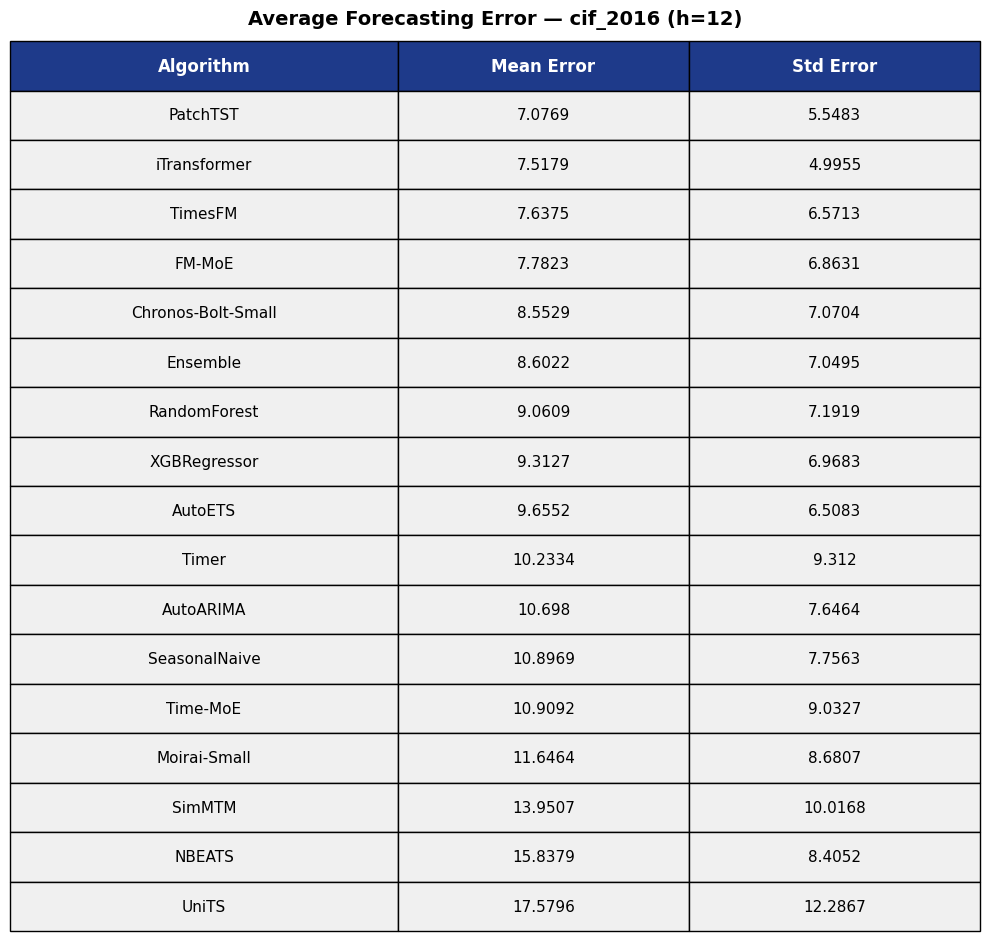

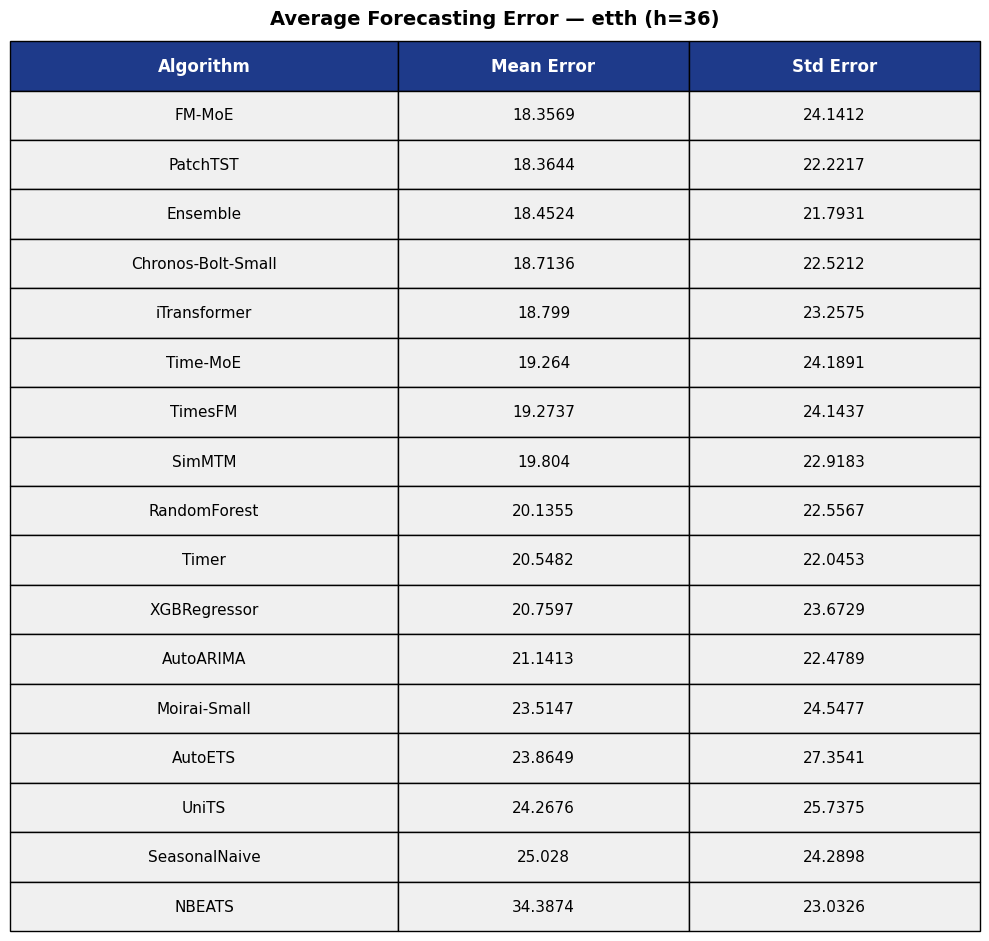

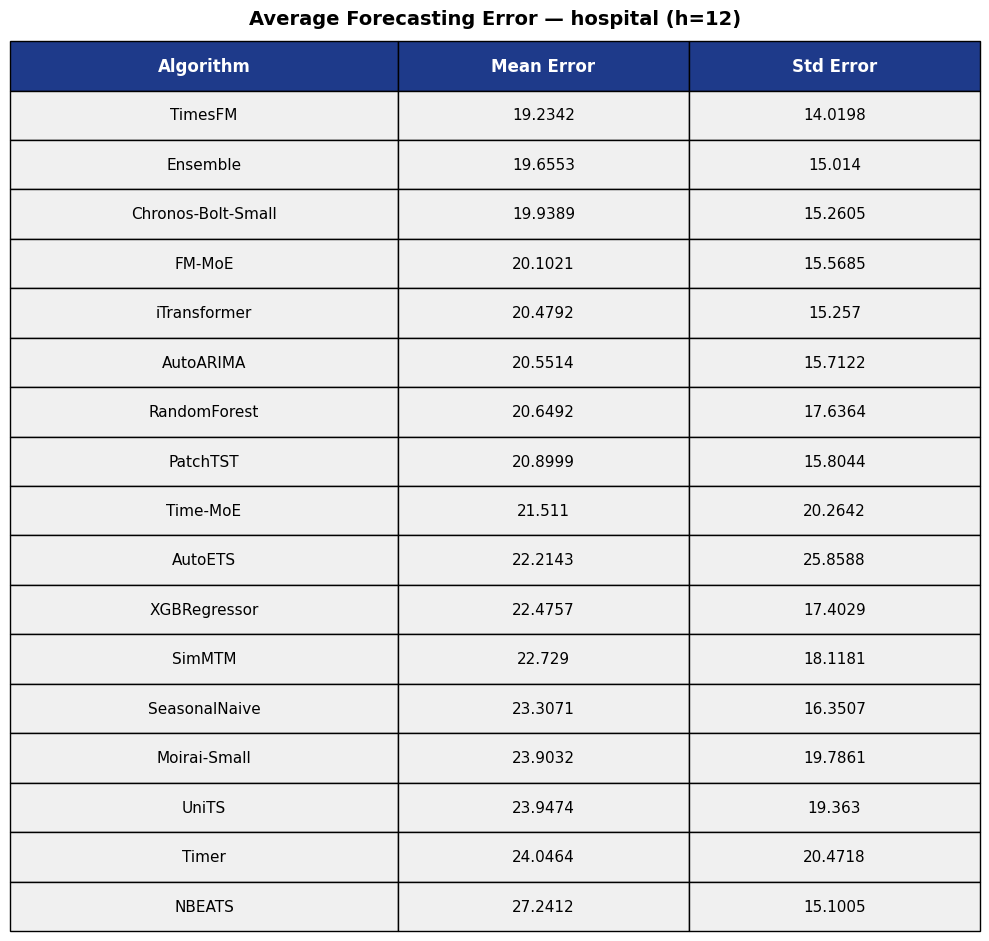

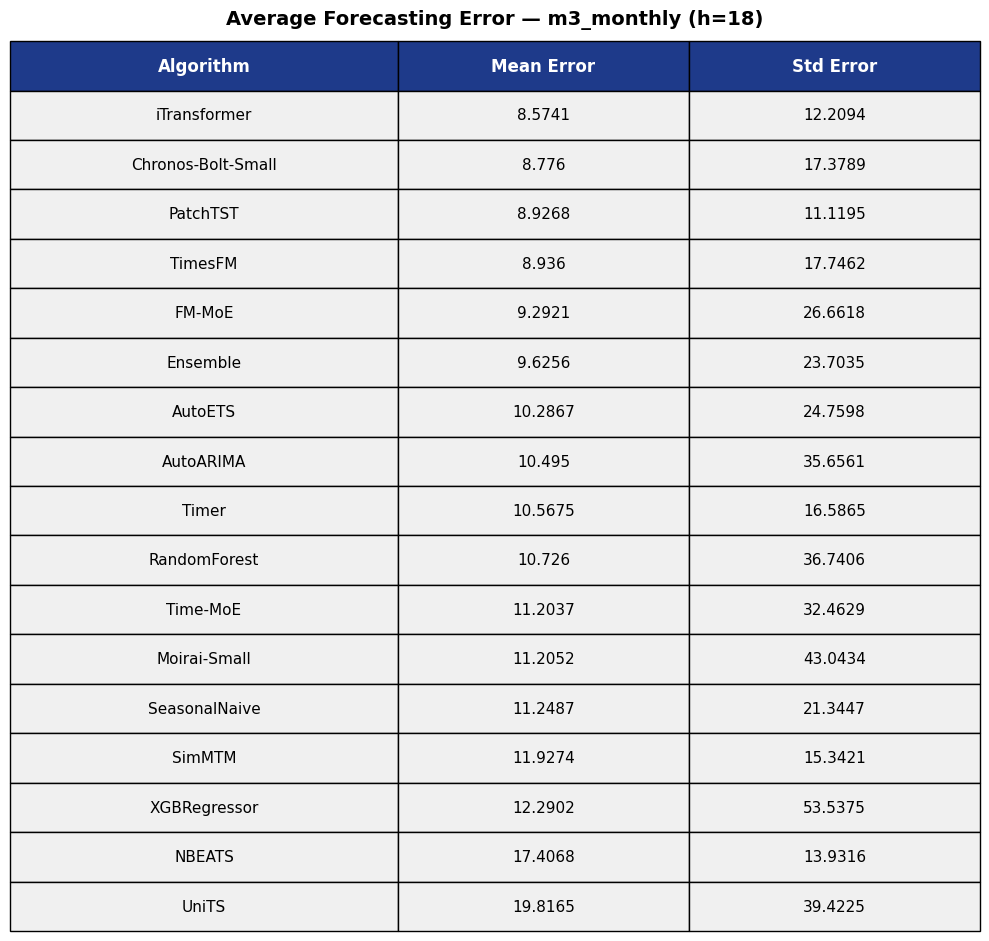

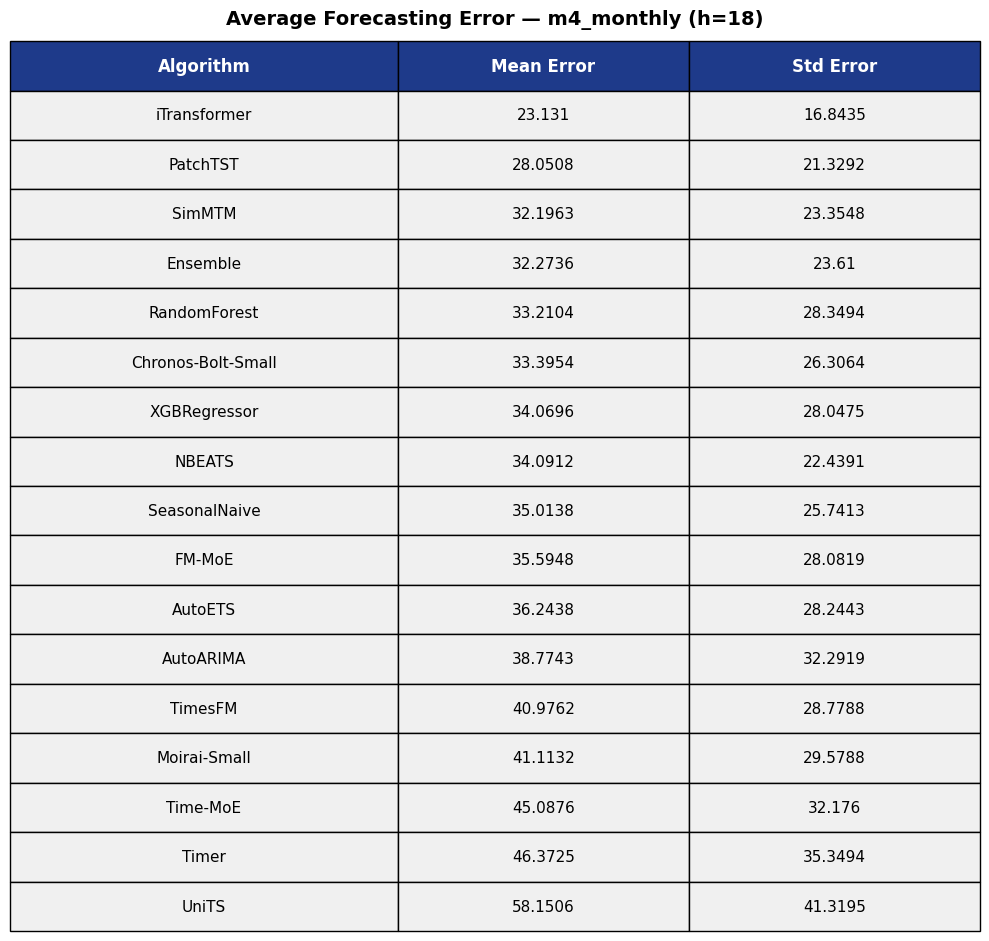

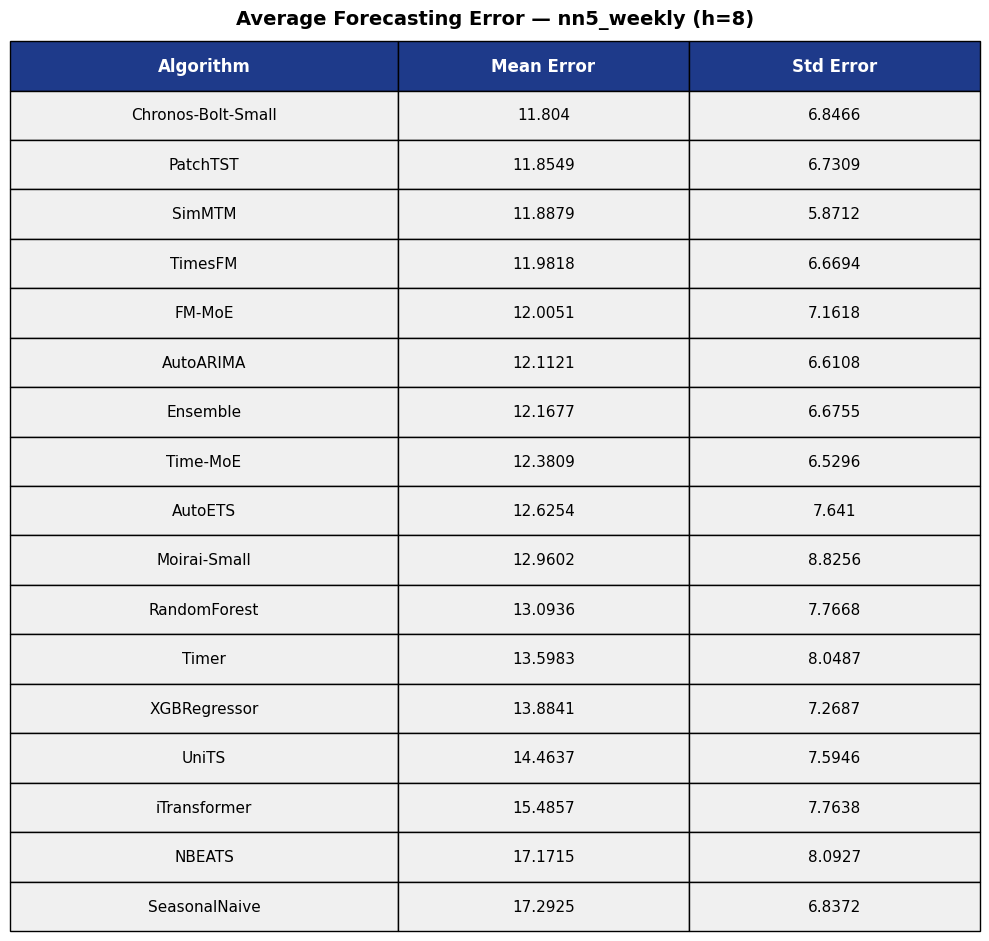

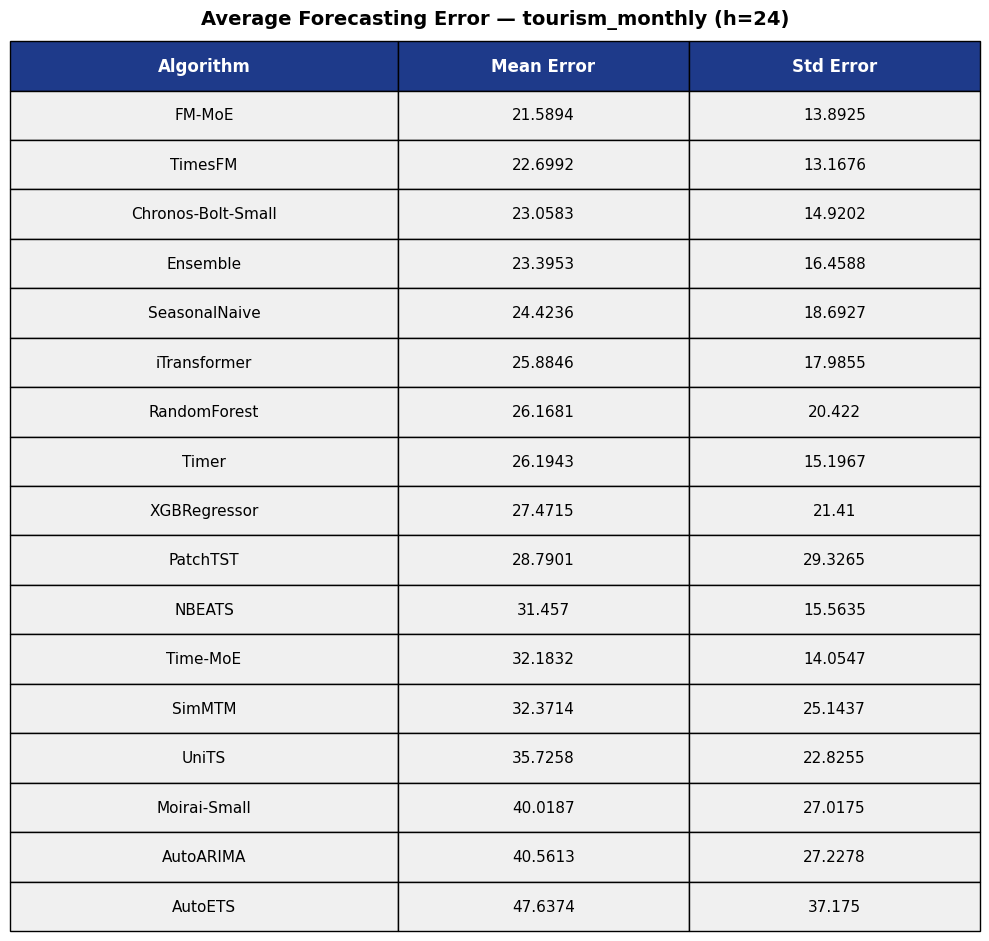


Tables successfully generated.

- Total records: 119
- Unique algorithms: 17
- Datasets: cif_2016, etth, hospital, m3_monthly, m4_monthly, nn5_weekly, tourism_monthly


In [1]:
# ==========================================================
# IMPORTS
# ==========================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ==========================================================
# CONFIGURATION
# ==========================================================
BASE_RESULTS_PATH = "RESULTADOS_FINAIS_BENCHMARK/results_benchmark"

# Diretório com modelos ADICIONAIS (ex.: UniTS, SimMTM) que devem ser
# incluídos em TODOS os datasets, independentemente do best_config. São
# carregados de results_<dataset>.csv nessa pasta e anexados aos modelos
# originais de cada dataset.
EXTRA_MODELS_PATH = "results_benchmark/novos_models"

# Pontos (séries/colunas) cujo erro "estoura" numericamente (ex.: 7.3e+17)
# distorcem completamente as médias e comparações. Qualquer ponto em que
# ALGUM modelo apresente |valor| > EXPLOSION_THRESHOLD é descartado para
# TODOS os modelos daquele benchmark, mantendo o alinhamento das comparações.
EXPLOSION_THRESHOLD = 1e6


def drop_exploded_points(df, dataset_name="", config_name="", threshold=EXPLOSION_THRESHOLD):
    """Remove os pontos com valores estourados (|valor| > threshold) de todos os
    modelos e informa quais pontos foram descartados. Retorna (df_limpo, pontos_descartados)."""
    metric_cols = [c for c in df.columns if c != "Modelo" and not str(c).startswith("Unnamed")]
    numeric = df[metric_cols].apply(pd.to_numeric, errors="coerce")
    exploded_mask = (numeric.abs() > threshold).any(axis=0)
    dropped = [c for c in metric_cols if bool(exploded_mask.get(c, False))]
    if dropped:
        label = dataset_name + (f" / {config_name}" if config_name else "")
        print(f"[ESTOURO] {label}: pontos descartados (|valor| > {threshold:g}): {dropped}")
    return df.drop(columns=dropped), dropped


def append_extra_models(df, results_filename, extra_path=EXTRA_MODELS_PATH):
    """Anexa ao df os modelos extras (ex.: UniTS, SimMTM) presentes em
    extra_path/<results_filename>, alinhando pelas colunas de série em comum.
    Modelos já presentes no df original não são duplicados. Se o arquivo não
    existir, retorna o df inalterado."""
    extra_file = os.path.join(extra_path, results_filename)
    if not os.path.exists(extra_file):
        return df
    df_extra = pd.read_csv(extra_file)
    common_cols = [c for c in df.columns if c in df_extra.columns]
    existing = set(df["Modelo"])
    df_extra = df_extra[~df_extra["Modelo"].isin(existing)]
    if df_extra.empty:
        return df
    print(f"[EXTRA] {results_filename}: modelos adicionados -> {list(df_extra['Modelo'])}")
    return pd.concat([df[common_cols], df_extra[common_cols]], ignore_index=True)

DATASETS = {
    "cif_2016_filtered":        {"horizon": 12, "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.001"},
    "etth_filtered":            {"horizon": 36, "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.001"},
    "hospital_filtered":        {"horizon": 12, "best_config": "topk_2_norm_std_noise_True_ep_60_lr_0.001"},
    "m3_monthly_filtered":      {"horizon": 18, "best_config": "topk_2_norm_std_noise_True_ep_30_lr_0.001"},
    "m4_monthly_filtered":      {"horizon": 18, "best_config": "topk_2_norm_std_noise_True_ep_30_lr_0.001"},
    "nn5_weekly_filtered":      {"horizon": 8,  "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.001"},
    "tourism_monthly_filtered": {"horizon": 24, "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.0001"},
    # "fred_bls_filtered":        {"horizon": 12, "best_config": "topk_2_norm_std_noise_True_ep_60_lr_0.001"},
    # "fred_md_filtered":         {"horizon": 12, "best_config": "topk_2_norm_std_noise_True_ep_30_lr_0.0001"},
    # "walmart_sales_filtered":   {"horizon": 5, "best_config": "topk_2_norm_std_noise_True_ep_30_lr_0.0001"},
    # "weather_filtered":         {"horizon": 36, "best_config": "topk_2_norm_std_noise_True_ep_100_lr_0.001"},
}

# ==========================================================
# LOAD RESULTS
# ==========================================================
rows_all = []
dropped_points_log = {}

for dataset_name, info in DATASETS.items():
    config = info["best_config"]
    horizon = info["horizon"]
    results_filename = f"results_{dataset_name}.csv"
    file_path = os.path.join(BASE_RESULTS_PATH, config, results_filename)

    if not os.path.exists(file_path):
        print(f"[WARNING] File not found: {file_path}")
        continue

    df = pd.read_csv(file_path)

    # Anexa os modelos extras (UniTS, SimMTM, ...) antes de qualquer limpeza,
    # para que o descarte de pontos estourados seja consistente entre TODOS
    # os modelos (originais + extras).
    df = append_extra_models(df, results_filename)

    # Descarta pontos estourados (mesmos pontos para todos os modelos)
    df, dropped = drop_exploded_points(df, dataset_name, config)
    if dropped:
        dropped_points_log[dataset_name] = dropped

    metric_cols = [c for c in df.columns if c != "Modelo" and not c.startswith("Unnamed")]

    for _, row in df.iterrows():
        values = row[metric_cols].values.astype(float)
        rows_all.append({
            "Algorithm": row["Modelo"],
            "Dataset": dataset_name.replace("_filtered", ""),
            "Horizon": horizon,
            "Mean Error": round(np.nanmean(values), 4),
            "Std Error": round(np.nanstd(values), 4),
            "Config": config
        })


# ==========================================================
# BUILD DATAFRAME
# ==========================================================
df_all = pd.DataFrame(rows_all)

if len(df_all) == 0:
    print("\n[ERROR] No data loaded. Check paths.")
else:
    print(f"\n[INFO] Total records loaded: {len(df_all)}")
    print(f"[INFO] Datasets processed: {df_all['Dataset'].nunique()}")
    print(f"[INFO] Datasets: {sorted(df_all['Dataset'].unique())}")
    print(f"[INFO] Algorithms: {sorted(df_all['Algorithm'].unique())}")
    if dropped_points_log:
        print("\n[INFO] Pontos descartados por estouro numérico:")
        for ds, pts in dropped_points_log.items():
            print(f"   - {ds}: {pts}")

    df_summary = df_all.copy()
    df_summary = df_summary.sort_values(["Dataset", "Mean Error"])

    # ======================================================
    # TABLE VISUALIZATION
    # ======================================================
    datasets = sorted(df_summary["Dataset"].unique())

    for dataset in datasets:
        df_d = df_summary[df_summary["Dataset"] == dataset].copy()
        horizon = df_d["Horizon"].iloc[0]

        df_d["Algorithm"] = df_d["Algorithm"].replace("FM-MoE", "FM-MoE")
        df_d["Algorithm"] = df_d["Algorithm"].replace("Morai", "Moirai")

        df_display = df_d[["Algorithm", "Mean Error", "Std Error"]].copy()

        df_display = df_display.sort_values("Mean Error").reset_index(drop=True)

        fig, ax = plt.subplots(figsize=(10, len(df_display) * 0.5 + 1))
        ax.axis("off")
        ax.axis("tight")

        colors = [["#F0F0F0"] * 3 for _ in df_display["Algorithm"]]

        table = ax.table(
            cellText=df_display.values,
            colLabels=df_display.columns,
            cellLoc="center",
            loc="center",
            colWidths=[0.4, 0.3, 0.3],
            cellColours=colors
        )

        table.auto_set_font_size(False)
        table.set_fontsize(11)
        table.scale(1, 2.5)

        for i in range(len(df_display.columns)):
            cell = table[(0, i)]
            cell.set_facecolor("#1E3A8A")
            cell.set_text_props(weight="bold", color="white", fontsize=12)

        plt.title(
            f"Average Forecasting Error — {dataset} (h={horizon})",
            fontsize=14,
            fontweight="bold",
            pad=20
        )

        plt.tight_layout()
        plt.show()

    print("\nTables successfully generated.")
    print(f"\n- Total records: {len(df_all)}")
    print(f"- Unique algorithms: {df_all['Algorithm'].nunique()}")
    print(f"- Datasets: {', '.join(datasets)}")